In [51]:
#> imports
import numpy as np
import scipy.stats as stats
import pymc as pm
from tqdm import tqdm

import corner
import seaborn as sns
import matplotlib.pyplot as plt

from ot import sliced_wasserstein_distance as swd

In [20]:
#> declarations
global bounds, d
bound = 10               # can be inf in principle, but with ABC there should be a region of interest
bounds = (-bound, bound) # upper and lower bounds for prior
d = 2                    # dimension, 2=bivariate
outDir = './data/'       # directory to put ABC files

**Prior** \
Drawing a random covariance matrix is difficult.

The prior here draws a Cholesky lower triangle matrix with a given standard deviation vector, "such that the underlying correlation matrices follow an LKJ distribution", that can be made into a covariance matrix.

Basically (from what I understand), the code draws a random correlation matrix first (this is simplier to do), then creates the Cholesky matrix. The cov can then be constructed by $\Sigma = LL^T$

The underlying idea is similar to that of 2000 Barnard, which constructs covariance matrices by decomposing them into a correlation matrix drawn from a (inverse) Wishart distribution and the standard deviation diagonal matrix: $\Sigma = \textup{diag}(\sigma) ~~R ~~\textup{diag}(\sigma)$

See:
- [More about Cholesky factors](https://mc-stan.org/docs/2_32/reference-manual/cholesky-factors-of-covariance-matrices-1.html)
- [LKJ Dist Wiki](https://en.wikipedia.org/wiki/Lewandowski-Kurowicka-Joe_distribution)
- [pymc.LKJCholeskyCov](https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.LKJCholeskyCov.html)
- [pymc.Uniform](https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.Uniform.html#pymc.Uniform)

In [21]:
#> returns a draw from the prior
def prior():

    #> unpacking global
    global bounds
    lb, ub = bounds
    
    #> drawing mean vector and standard deviations
    mu_model = pm.Uniform.dist(lower=lb, upper=ub, shape=d)
    sigma_model = pm.Uniform.dist(lower=(ub-lb)/1e3, upper=(ub-lb)/1e1, size=d)

    #> LKJ random correlation matrix R
    eta = 1.0     # uniform
    n = d         # num dims
    cov_model = pm.LKJCholeskyCov.dist(eta=eta, n=n, sd_dist=sigma_model)

    mu = pm.draw(mu_model)
    chol, corr, sigmas = pm.draw(cov_model)
    cov = chol @ chol.T # equiv to cov = np.diag(sigmas) @ corr @ np.diag(sigmas)

    return mu, cov

**Model** \
Model draws from [scipy.stats.multivariate_normal](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html)

In [22]:
#> draws samples from bivariate normal
def model(mu, cov, num_samples):
    return stats.multivariate_normal.rvs(mean=mu, cov=cov, size=num_samples)

**Metric**\
The distance between two samples is given by the Sliced Wasserstein (SW) distance. 

The metric works by 'slicing' higher-dimensional data with the radon transform, then comparing with the closed from 1D Wasserstein distance. A large number of slices, $L$, will be more accurate, but take longer to compute.

See [ot.sliced_wasserstein_distance](https://pythonot.github.io/all.html#ot.sliced_wasserstein_distance)

In [23]:
#> returns the SW distance between two samples
def metric(sample1, sample2, L):
    return swd(sample1, sample2, n_projections=L)

**Creating Obs Sample** \
Creating an 'observed' sample and initializing txt files

In [24]:
#> creates observed sample
def obs(outFile='', num_samples=1000):

    #> drawing sample
    mu, cov = prior()
    sample = model(mu, cov, num_samples)

    #> saving if requested
    if outFile != '':
        with open(outFile, 'w') as F:
            F.write(f'{mu}\t{cov.flatten()}\n')
            for line in sample:
                F.write(f'{line}\n')
        
    return mu, cov, sample

In [49]:
#> file declarations
outFile_obs = outDir + 'wabc_bivariate_obs.txt'
outFile_mock = outDir + 'wabc_bivariate_mock.txt'

#> if wanting to create obs sample
createObs = False
if createObs: 
    #> creating 'observed' sample
    obs_mu, obs_cov, obs_sample = obs(outFile_obs, num_samples=1000)
    obs_cov = np.delete(obs_cov.flatten(), 2)
    
    #> clearing mock outFile (new obs --> new mocks)
    F = open(outFile_mock, 'w'); F.close()
else:
    #> loading obs data
    with open(outFile_obs, 'r') as F:

        #> reading first line
        obs_mu, obs_cov = F.readline().split('\t')

        #> converting
        obs_mu = obs_mu.replace('[','').replace(']','').split(' ')[1:]
        obs_cov = obs_cov.replace('[','').replace(']','').split(' ')[0:]
        obs_mu = np.array([float(x) for x in obs_mu])
        obs_cov = np.array([float(x) for x in obs_cov])
        obs_cov = np.delete(obs_cov, 2)

#> saving truth to be compared later
truth = np.hstack([obs_mu, obs_cov])

print(obs_cov)

#> printing obs
print(f'> Observed mu={obs_mu}')
print(f'> Observed cov={obs_cov}')

[0.26670321 0.22627589 0.75509582]
> Observed mu=[ 1.73365891 -3.56008276]
> Observed cov=[0.26670321 0.22627589 0.75509582]


**Running the ABC**

In [29]:
#> the main ABC function
def abc(outFile, obs_sample, num_samples):

    #> declarations
    num_mock_samples = len(obs_sample)       # same size mock vs. obs
    num_slices = 100                         # number of SW slices

    with open(outFile, 'ab') as F:           # opening outFile
        for num in tqdm(range(num_samples)): # running thru a set num of samples
            mu, cov = prior()                # drawing mock params
            mock_sample = model(mu, cov, num_samples=num_mock_samples) # drawing mock sample
            sw_dist = metric(obs_sample, mock_sample, num_slices)      # comparing samples
            cov = np.delete(cov.flatten(), 2)                          # deletes repeat cov
            array = np.hstack([mu, cov, sw_dist])                      # compiles

            #> writing to file
            if num != 0: F.write(b'\n')
            np.savetxt(F, array, newline=' ')
        F.write(b'\n')

    #> print statements
    print(f'> Sampling is complete!')
    print(f'> The {num_samples} samples were written to {outFile}')
    
    return

In [30]:
#> runs the abc
num_samples = 20000
abc(outFile_mock, obs_sample, num_samples)

NameError: name 'outFile' is not defined

**Reading Mock Samples** \
Array format: $[\mu_1, \mu_2, \Sigma_{11}, \Sigma_{12}, \Sigma_{22}, SW]$

See [corner.corner()](https://corner.readthedocs.io/en/latest/api/#corner.corner)

> There are 30000 samples!
> Posterior contains 100 samples or 0.33333333333333337% of data.
[ 1.73365891 -3.56008276  0.26670321  0.22627589  0.75509582]


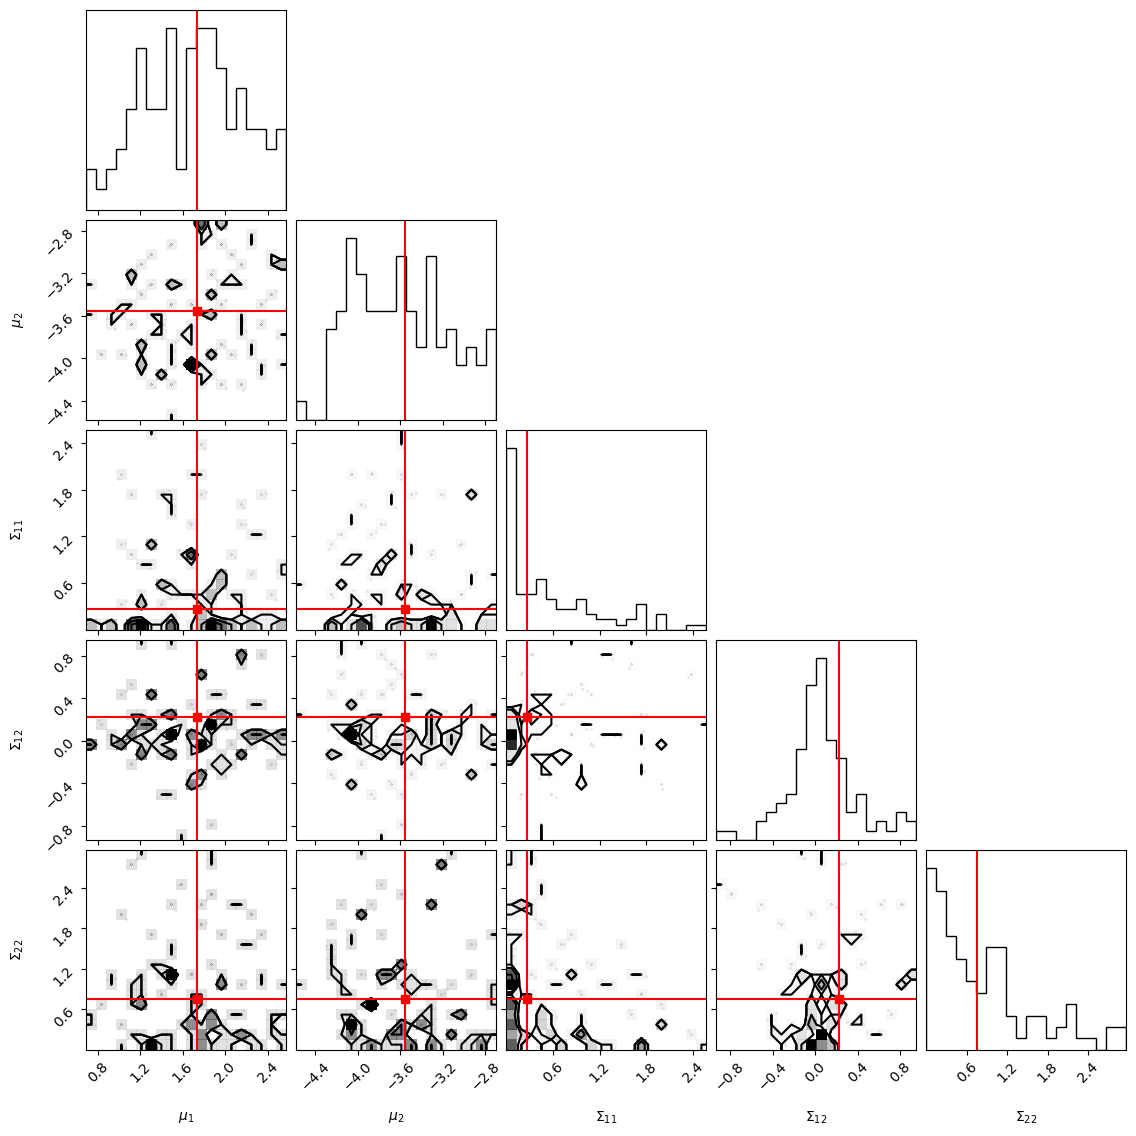

In [50]:
#> loading text files
mock_data = np.loadtxt(outFile_mock)

print(f'> There are {len(mock_data)} samples!')

#> labels
labels = [r'$\mu_1$', r'$\mu_2$', 
          r'$\Sigma_{11}$', r'$\Sigma_{12}$', r'$\Sigma_{22}$']

#> checking posterior
num_post = 100                  # number of samples in posterior
posterior = mock_data[ np.argsort(mock_data[:,-1]) ][:num_post]

# epsilon_perc = 0.10 # % of mock_data taken for posterior
# threshold = np.percentile(mock_data[:,-1], 100-(epsilon_perc*100))
# posterior = mock_data[ mock_data[:,-1] >= threshold ]

print(f'> Posterior contains {len(posterior)} samples or {len(posterior)/len(mock_data)*100}% of data.')

print(truth)

#> plotting posterior
fig = corner.corner(posterior[:,:-1], labels=labels, 
                    truths=truth, truth_color='r')

**Checking Convergence**